In [ ]:
import numpy as np

import matplotlib.pyplot as plt


In [3]:
%matplotlib widget
LINE_WIDTH = 2
FONT_SIZE = 12
col = np.array(
    [
        [1, 0, 0],
        [0, 0, 1],
        [0, 0.8, 0],
        [0.4, 0.4, 0],
        [0, 0.8, 0.8],
        [0.4, 0, 0.8],
        [0.8, 0.4, 1],
        [0.4, 0.4, 1],
    ]
)

In [7]:
all_H = []
all_mix = []
all_fecg = []
all_mecg = []
for i in range(200):
    with open(f"Foetus_{i}.pkl", "rb") as f:
        if i % 10 == 0:
            print(i)
        temp_file = pickle.load(f)
        all_H.append(temp_file["f_model"][0]["H"])
        all_mix.append(temp_file["mixture"])
        all_mecg.append(temp_file["mecg"])
        all_fecg.append(temp_file["fecg"][0])

FileNotFoundError: [Errno 2] No such file or directory: 'Foetus_0.pkl'

In [4]:
def pol2cart(rho, phi, z=None):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    if z is not None:
        return x, y, z
    return x, y

In [5]:
def svd_vals(A):
    return svd(A, compute_uv=False)


def metrics_for_set(S, all_H):
    sig3_vals = []
    volumes = []

    for H in all_H:
        A = H[list(S), :]
        if A.shape[0] < 3:
            sig3_vals.append(0.0)
            volumes.append(0.0)
            continue

        s = svd_vals(A)
        sig3_vals.append(s[-1])
        volumes.append(s[0] * s[1] * s[2])

    return np.array(sig3_vals), np.array(volumes)


def combined_score(S, all_H, q=10, w1=1.0, w2=0.2):
    sig3_vals, volumes = metrics_for_set(S, all_H)

    # робастность
    f1 = np.percentile(sig3_vals, q)

    # максимум объёма
    f2 = np.max(volumes)

    # лог для стабилизации
    f2_log = np.log(f2 + 1e-12)

    return w1 * f1 + w2 * f2_log


def find_top_triples_with_print(all_H, top_n=10, q=10, w1=1.0, w2=0.2):
    N_el = all_H[0].shape[0]
    scored = []

    for S in combinations(range(N_el), 3):
        sc = combined_score(S, all_H, q=q, w1=w1, w2=w2)
        scored.append((sc, S))

    # сортировка по убыванию
    scored.sort(key=lambda x: x[0], reverse=True)

    # вывод топ-N
    print(f"\nTop {top_n} triples:\n")
    for i, (sc, S) in enumerate(scored[:top_n], 1):
        print(f"{i:2d}. Electrodes {S} -> score = {sc:.6f}")

    return scored[:top_n]


def find_top_quads_from_triples(top_triples, all_H, top_n=10, q=10, w1=1.0, w2=0.2):
    N_el = all_H[0].shape[0]
    scored_quads = []

    for _, S3 in top_triples:
        S3_set = set(S3)

        for e in range(N_el):
            if e in S3_set:
                continue

            S4 = tuple(sorted((*S3, e)))
            sc = combined_score(S4, all_H, q=q, w1=w1, w2=w2)
            scored_quads.append((sc, S4))

    # убираем дубликаты (разные тройки могут дать одну четвёрку)
    scored_quads = list({S: sc for sc, S in scored_quads}.items())
    scored_quads = [(sc, S) for S, sc in scored_quads]

    scored_quads.sort(key=lambda x: x[0], reverse=True)

    print(f"\nTop {top_n} quadruples:\n")
    for i, (sc, S) in enumerate(scored_quads[:top_n], 1):
        print(f"{i:2d}. {S} -> score = {sc:.6f}")

    return scored_quads[:top_n]


def run_selection(all_H, top_n=10):
    top_triples = find_top_triples_with_print(all_H, top_n=top_n)
    top_quads = find_top_quads_from_triples(top_triples, all_H, top_n=top_n)
    return top_triples, top_quads

In [6]:
top_triples, top_quads = run_selection(np.array(all_H), top_n=30)


Top 30 triples:

 1. Electrodes (14, 33, 37) -> score = 3.277172
 2. Electrodes (14, 32, 36) -> score = 3.273444
 3. Electrodes (13, 32, 36) -> score = 3.269179
 4. Electrodes (12, 17, 34) -> score = 3.267269
 5. Electrodes (6, 16, 70) -> score = 3.264311
 6. Electrodes (6, 15, 69) -> score = 3.261130
 7. Electrodes (12, 16, 34) -> score = 3.259791
 8. Electrodes (6, 13, 50) -> score = 3.254621
 9. Electrodes (6, 15, 70) -> score = 3.250343
10. Electrodes (6, 14, 69) -> score = 3.248753
11. Electrodes (11, 16, 34) -> score = 3.248623
12. Electrodes (14, 33, 36) -> score = 3.248270
13. Electrodes (5, 12, 48) -> score = 3.245545
14. Electrodes (6, 14, 70) -> score = 3.244949
15. Electrodes (6, 15, 68) -> score = 3.244936
16. Electrodes (11, 15, 34) -> score = 3.244920
17. Electrodes (6, 13, 49) -> score = 3.243636
18. Electrodes (6, 17, 71) -> score = 3.242917
19. Electrodes (6, 14, 49) -> score = 3.242795
20. Electrodes (7, 17, 70) -> score = 3.241603
21. Electrodes (5, 14, 68) -> scor

hearts: (-np.pi / 4, np.pi / 4) & elpos: (-np.pi / 4, np.pi / 4) = (6, 15, 68, 99) & (1, 12, 86, 99)



hearts: (-np.pi / 3, np.pi / 3) & elpos: (-np.pi / 5, np.pi / 5) = (6, 15, 68, 99) & (4, 8, 22, 60)

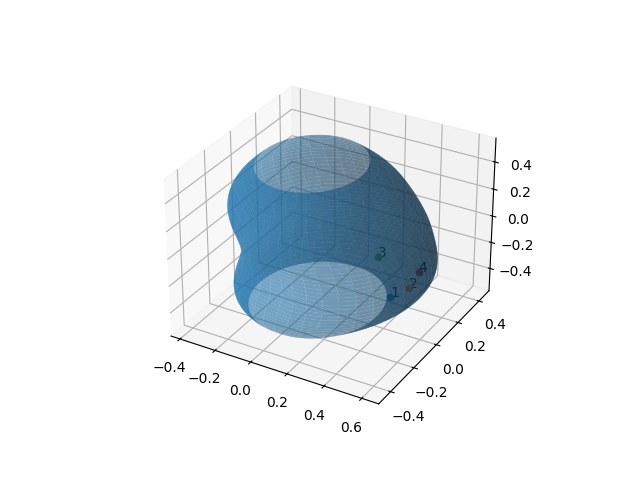

In [7]:
import numpy as np

import matplotlib.pyplot as plt

R_chest = 0.35
R_hips = 0.4
R_belly = 0.1

%matplotlib widget
LINE_WIDTH = 2
FONT_SIZE = 12
col = np.array(
    [
        [1, 0, 0],
        [0, 0, 1],
        [0, 0.8, 0],
        [0.4, 0.4, 0],
        [0, 0.8, 0.8],
        [0.4, 0, 0.8],
        [0.8, 0.4, 1],
        [0.4, 0.4, 1],
    ]
)


def pol2cart(rho, phi, z=None):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    if z is not None:
        return x, y, z
    return x, y


# форма
a = 8.0
c = 6.0

v0 = -0.1  # центр живота
w = 0.3

u = np.linspace(0, 2 * np.pi, 120)
v = np.linspace(-0.5, 0.5, 120)
u, v = np.meshgrid(u, v)

R_base = R_chest * np.exp(-a * (v - 0.3) ** 2) + R_hips * np.exp(-c * (v + 0.3) ** 2)

belly_profile = 1 / (1 + ((v - v0) / w) ** 4)
front = np.maximum(0, np.cos(u))

belly = R_belly * belly_profile * front

R = R_base + belly

x = R * np.cos(u)
x += 0.1 * np.exp(-10 * (v - v0) ** 2)
y = R * np.sin(u)
z = v
R_heart = 0.07
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(x, y, z, alpha=0.6)

n_phi_pts = 7  # количество по углу
n_z_pts = 3
z_lin_pts = np.linspace(-0.35, 0.15, n_z_pts)
phi_pts = np.linspace(-np.pi / 5, np.pi / 5, n_phi_pts)
phi_pts, z_lin_pts = np.meshgrid(phi_pts, z_lin_pts)
# --- ВОССТАНАВЛИВАЕМ РАДИУС (ТА ЖЕ ФОРМУЛА!) ---

# базовая форма
R_base_pts = R_chest * np.exp(-a * (z_lin_pts - 0.3) ** 2) + R_hips * np.exp(
    -c * (z_lin_pts + 0.3) ** 2
)

# профиль живота (тот же!)
belly_profile_pts = 1 / (1 + ((z_lin_pts - v0) / w) ** 4)

# только спереди
front_pts = np.maximum(0, np.cos(phi_pts))

# живот
belly_pts = R_belly * belly_profile_pts * front_pts

# итоговый радиус
R_pts = R_base_pts + belly_pts

# --- ПЕРЕВОД В ДЕКАРТОВЫ ---
x_pts = R_pts * np.cos(phi_pts)
x_pts += 0.1 * np.exp(-10 * (z_lin_pts - v0) ** 2)
y_pts = R_pts * np.sin(phi_pts)
z_pts = z_lin_pts

x_center = 0.1 * np.exp(-10 * (z_lin_pts - v0) ** 2)
R_true = np.sqrt(x_pts**2 + y_pts**2)
phi_true = np.arctan2(y_pts, x_pts)
phi_flat = phi_true.flatten()
r_flat = R_true.flatten()
z_flat = z_lin_pts.flatten()

points_cyl = np.column_stack((phi_flat, r_flat, z_flat))

#  1. comb = [4, 5, 6], ref = 14 -> score = 0.546
#  2. comb = [3, 4, 6], ref = 14 -> score = 0.534
#  3. comb = [7, 8, 14], ref = 6 -> score = 0.529
#  4. comb = [8, 9, 15], ref = 6 -> score = 0.528
#  5. comb = [7, 8, 9], ref = 6 -> score = 0.527
#  6. comb = [2, 14, 15], ref = 6 -> score = 0.526
#  7. comb = [7, 9, 14], ref = 6 -> score = 0.526
#  8. comb = [7, 9, 15], ref = 6 -> score = 0.526
#  9. comb = [3, 5, 6], ref = 14 -> score = 0.525
# 10. comb = [8, 14, 15], ref = 6 -> score = 0.525
# 11. comb = [9, 14, 15], ref = 6 -> score = 0.525
# 12. comb = [0, 8, 14], ref = 6 -> score = 0.524
# 13. comb = [4, 5, 6], ref = 15 -> score = 0.524
# 14. comb = [7, 8, 10], ref = 6 -> score = 0.524
# 15. comb = [9, 15, 16], ref = 6 -> score = 0.523
# 16. comb = [0, 8, 15], ref = 6 -> score = 0.522
# 17. comb = [1, 7, 14], ref = 6 -> score = 0.522
# 18. comb = [2, 7, 14], ref = 6 -> score = 0.522
# 19. comb = [3, 4, 5], ref = 14 -> score = 0.522
# 20. comb = [7, 8, 15], ref = 6 -> score = 0.522
# 21. comb = [7, 14, 16], ref = 6 -> score = 0.522
# 22. comb = [1, 8, 15], ref = 6 -> score = 0.521
# 23. comb = [4, 6, 13], ref = 14 -> score = 0.521
# 24. comb = [0, 14, 15], ref = 6 -> score = 0.52
# 25. comb = [7, 14, 15], ref = 5 -> score = 0.52
# 26. comb = [8, 15, 16], ref = 6 -> score = 0.52
# 27. comb = [10, 15, 16], ref = 6 -> score = 0.52
# 28. comb = [1, 8, 14], ref = 6 -> score = 0.519
# 29. comb = [1, 14, 15], ref = 6 -> score = 0.519
# 30. comb = [10, 14, 15], ref = 6 -> score = 0.519
comb = [8, 9, 15]
ref = 6
best_id = [*comb, ref]
for i, (phi, r, z) in enumerate(points_cyl[best_id]):
    x, y, z = pol2cart(r, phi, z)
    ax.scatter(x, y, z, s=20)
    ax.text(x, y, z, str(i + 1))

plt.ion()
plt.show()

In [14]:
ab = np.vstack([points_cyl, a])

In [15]:
ab

array([[-0.56595596,  0.5048265 , -0.35      ],
       [-0.4397269 ,  0.51340545, -0.35      ],
       [-0.31385128,  0.51997811, -0.35      ],
       [-0.18821719,  0.52442654, -0.35      ],
       [-0.06272368,  0.5266709 , -0.35      ],
       [ 0.06272368,  0.5266709 , -0.35      ],
       [ 0.18821719,  0.52442654, -0.35      ],
       [ 0.31385128,  0.51997811, -0.35      ],
       [ 0.4397269 ,  0.51340545, -0.35      ],
       [ 0.56595596,  0.5048265 , -0.35      ],
       [-0.54080812,  0.57524769, -0.225     ],
       [-0.42033709,  0.58791978, -0.225     ],
       [-0.30009499,  0.5976254 , -0.225     ],
       [-0.18000157,  0.60419293, -0.225     ],
       [-0.05999157,  0.60750607, -0.225     ],
       [ 0.05999157,  0.60750607, -0.225     ],
       [ 0.18000157,  0.60419293, -0.225     ],
       [ 0.30009499,  0.5976254 , -0.225     ],
       [ 0.42033709,  0.58791978, -0.225     ],
       [ 0.54080812,  0.57524769, -0.225     ],
       [-0.52623157,  0.57677047, -0.1  

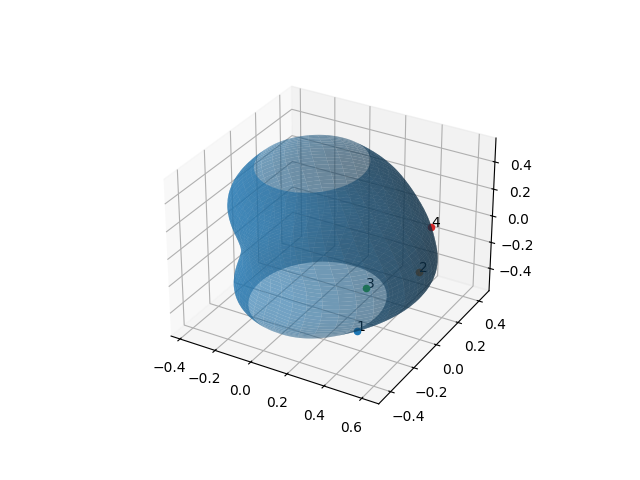

In [11]:
R_chest = 0.35
R_hips = 0.4
R_belly = 0.1
best_id = [0, 6, 14, 20]


def plot_sphere(center_cyl, radius, label):
    phi_c, r_c, z_c = center_cyl
    xc, yc, zc = pol2cart(r_c, phi_c, z_c)

    u = np.linspace(0, 2 * np.pi, 120)
    v = np.linspace(0, np.pi, 120)
    u, v = np.meshgrid(u, v)

    xs = xc + radius * np.cos(u) * np.sin(v)
    ys = yc + radius * np.sin(u) * np.sin(v)
    zs = zc + radius * np.cos(v)

    ax.plot_surface(xs, ys, zs, color="r", alpha=1)
    ax.text(xc, yc, zc, label)


# форма
a = 8.0
c = 6.0

v0 = -0.1  # центр живота
w = 0.3

u = np.linspace(0, 2 * np.pi, 120)
v = np.linspace(-0.5, 0.5, 120)
u, v = np.meshgrid(u, v)

R_base = R_chest * np.exp(-a * (v - 0.3) ** 2) + R_hips * np.exp(-c * (v + 0.3) ** 2)

belly_profile = 1 / (1 + ((v - v0) / w) ** 4)
front = np.maximum(0, np.cos(u))

belly = R_belly * belly_profile * front

R = R_base + belly

x = R * np.cos(u)
x += 0.1 * np.exp(-10 * (v - v0) ** 2)
y = R * np.sin(u)
z = v
R_heart = 0.07
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(x, y, z, alpha=0.6)

n_phi_pts = 7  # количество по углу
n_z_pts = 3
z_lin_pts = np.linspace(-0.35, 0.0, n_z_pts)
phi_pts = np.linspace(-np.pi / 5, np.pi / 5, n_phi_pts)
phi_pts, z_lin_pts = np.meshgrid(phi_pts, z_lin_pts)
# --- ВОССТАНАВЛИВАЕМ РАДИУС (ТА ЖЕ ФОРМУЛА!) ---

# базовая форма
R_base_pts = R_chest * np.exp(-a * (z_lin_pts - 0.3) ** 2) + R_hips * np.exp(
    -c * (z_lin_pts + 0.3) ** 2
)

# профиль живота (тот же!)
belly_profile_pts = 1 / (1 + ((z_lin_pts - v0) / w) ** 4)

# только спереди
front_pts = np.maximum(0, np.cos(phi_pts))

# живот
belly_pts = R_belly * belly_profile_pts * front_pts

# итоговый радиус
R_pts = R_base_pts + belly_pts

# --- ПЕРЕВОД В ДЕКАРТОВЫ ---
x_pts = R_pts * np.cos(phi_pts)
x_pts += 0.1 * np.exp(-10 * (z_lin_pts - v0) ** 2)
y_pts = R_pts * np.sin(phi_pts)
z_pts = z_lin_pts

x_center = 0.1 * np.exp(-10 * (z_lin_pts - v0) ** 2)
R_true = np.sqrt(x_pts**2 + y_pts**2)
phi_true = np.arctan2(y_pts, x_pts)
phi_flat = phi_true.flatten()
r_flat = R_true.flatten()
z_flat = z_lin_pts.flatten()

points_cyl = np.column_stack((phi_flat, r_flat, z_flat))
# # --- ОТРИСОВКА ---
# ax.scatter(x_pts, y_pts, z_pts, s=15)

for i, (phi, r, z) in enumerate(points_cyl[best_id]):
    x, y, z = pol2cart(r, phi, z)
    ax.scatter(x, y, z, s=20)
    ax.text(x, y, z, str(i + 1))

plt.ion()
plt.show()

In [ ]:
points_cyl.append()

array([[-0.72127951,  0.44867634, -0.4       ],
       [-0.64476211,  0.45359082, -0.4       ],
       [-0.56845032,  0.45804092, -0.4       ],
       [-0.49231533,  0.46199841, -0.4       ],
       [-0.41633008,  0.46543825, -0.4       ],
       [-0.34046896,  0.46833867, -0.4       ],
       [-0.26470767,  0.47068131, -0.4       ],
       [-0.18902293,  0.47245137, -0.4       ],
       [-0.11339229,  0.47363767, -0.4       ],
       [-0.03779386,  0.4742327 , -0.4       ],
       [ 0.03779386,  0.4742327 , -0.4       ],
       [ 0.11339229,  0.47363767, -0.4       ],
       [ 0.18902293,  0.47245137, -0.4       ],
       [ 0.26470767,  0.47068131, -0.4       ],
       [ 0.34046896,  0.46833867, -0.4       ],
       [ 0.41633008,  0.46543825, -0.4       ],
       [ 0.49231533,  0.46199841, -0.4       ],
       [ 0.56845032,  0.45804092, -0.4       ],
       [ 0.64476211,  0.45359082, -0.4       ],
       [ 0.72127951,  0.44867634, -0.4       ],
       [-0.69554493,  0.52822391, -0.3  

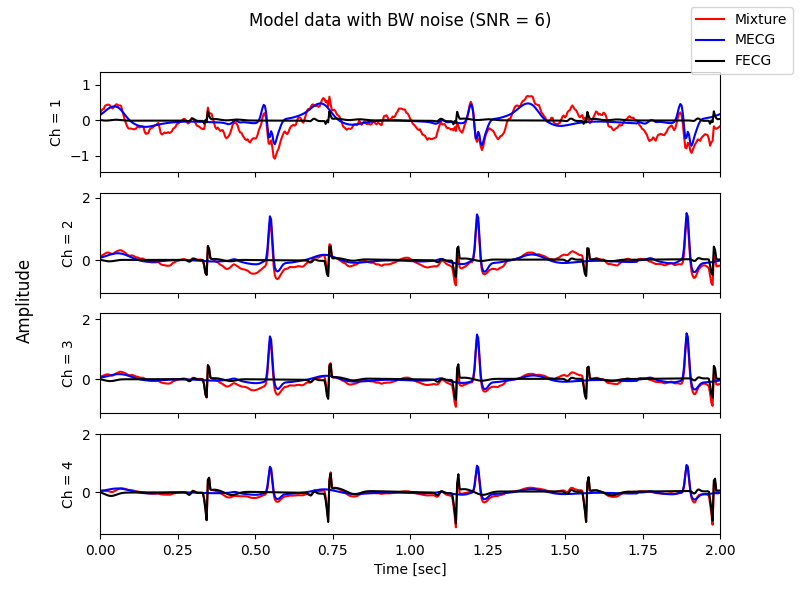

In [17]:
w_id = 0
fig, ax = plt.subplots(4, 1, figsize=(8, 6), sharex=True)
fig.suptitle("Model data with BW noise (SNR = 6)")

for i in range(4):
    ax[i].plot(x_plot, temp_file["mixture"][i], "r")
    ax[i].plot(x_plot, temp_file["mecg"][i], "b")
    ax[i].plot(x_plot, temp_file["fecg"][0][i], "k")

    ax[i].set_ylabel(f"Ch = {i + 1}")
    ax[i].set_xlim(0, 2)

ax[-1].set_xlabel("Time [sec]")
fig.supylabel("Amplitude")
fig.legend(["Mixture", "MECG", "FECG"])
fig.savefig("BW_Noise_Signal.png")